<a href="https://colab.research.google.com/github/Shayanakbar90/CodeAlpha-MusicGenerationAI/blob/main/music_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q music21

In [2]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from music21 import chord, converter, instrument, note, stream

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")

TensorFlow version: 2.20.0
Libraries imported successfully.


In [3]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
from music21 import corpus

midi_folder = Path("/content/midi_dataset")
midi_folder.mkdir(parents=True, exist_ok=True)

bach_works = corpus.getComposer("bach")[:20]
saved_files = []

for index, work in enumerate(bach_works, start=1):
    try:
        score = corpus.parse(work)

        output_file = midi_folder / f"bach_piece_{index:02d}.mid"
        score.write("midi", fp=str(output_file))

        saved_files.append(output_file.name)

    except Exception as error:
        print(f"Skipped {work}: {error}")

print(f"Created {len(saved_files)} MIDI files.")
print("First five files:", saved_files[:5])

Created 20 MIDI files.
First five files: ['bach_piece_01.mid', 'bach_piece_02.mid', 'bach_piece_03.mid', 'bach_piece_04.mid', 'bach_piece_05.mid']


In [6]:
music_events = []

midi_files = sorted(midi_folder.glob("*.mid"))

for midi_file in midi_files:
    try:
        score = converter.parse(str(midi_file))

        # Convert different musical parts into one chord-based timeline
        chordified_score = score.chordify()

        for element in chordified_score.recurse().notes:
            duration = round(float(element.duration.quarterLength), 2)

            if duration <= 0:
                continue

            if isinstance(element, note.Note):
                event = (
                    f"NOTE:{element.pitch.nameWithOctave}"
                    f"|DURATION:{duration}"
                )

            elif isinstance(element, chord.Chord):
                pitches = ".".join(
                    str(pitch.midi) for pitch in element.pitches
                )

                event = (
                    f"CHORD:{pitches}"
                    f"|DURATION:{duration}"
                )

            else:
                continue

            music_events.append(event)

    except Exception as error:
        print(f"Could not process {midi_file.name}: {error}")


print("MIDI files processed:", len(midi_files))
print("Total musical events:", len(music_events))
print("Unique musical events:", len(set(music_events)))
print("\nFirst 10 events:")

for event in music_events[:10]:
    print(event)

MIDI files processed: 20
Total musical events: 1926
Unique musical events: 1066

First 10 events:
CHORD:53.57.60.65|DURATION:1.0
CHORD:52.55.60.67.72|DURATION:0.5
CHORD:52.55.60.72|DURATION:0.5
CHORD:53.57.60.65.69|DURATION:0.5
CHORD:53.57.60.69|DURATION:0.5
CHORD:50.57.62.65|DURATION:0.5
CHORD:50.53.57.62.65|DURATION:0.5
CHORD:45.57.65.72|DURATION:0.5
CHORD:45.57.60.65.72|DURATION:0.5
CHORD:46.53.65.70.74|DURATION:0.25


In [7]:
sequence_length = 50

# Create a vocabulary of all unique notes and chords
event_names = sorted(set(music_events))
event_to_int = {
    event: index
    for index, event in enumerate(event_names)
}
int_to_event = {
    index: event
    for event, index in event_to_int.items()
}

vocabulary_size = len(event_names)

input_sequences = []
target_events = []

for start_index in range(len(music_events) - sequence_length):
    sequence = music_events[
        start_index:start_index + sequence_length
    ]
    target = music_events[
        start_index + sequence_length
    ]

    input_sequences.append(
        [event_to_int[event] for event in sequence]
    )
    target_events.append(event_to_int[target])

if not input_sequences:
    raise ValueError(
        "Not enough musical events were extracted to create sequences."
    )

X = np.asarray(input_sequences, dtype=np.int32)
y = np.asarray(target_events, dtype=np.int32)

# Shuffle the data reproducibly
random_generator = np.random.default_rng(42)
indexes = random_generator.permutation(len(X))

X = X[indexes]
y = y[indexes]

# Use 90% for training and 10% for validation
split_index = int(len(X) * 0.90)

X_train = X[:split_index]
y_train = y[:split_index]

X_validation = X[split_index:]
y_validation = y[split_index:]

print("Vocabulary size:", vocabulary_size)
print("Total sequences:", len(X))
print("Training sequences:", len(X_train))
print("Validation sequences:", len(X_validation))
print("Input shape:", X_train.shape)
print("Target shape:", y_train.shape)

Vocabulary size: 1066
Total sequences: 1876
Training sequences: 1688
Validation sequences: 188
Input shape: (1688, 50)
Target shape: (1688,)


In [8]:
sequence_length = 50

# Create a vocabulary of all unique notes and chords
event_names = sorted(set(music_events))
event_to_int = {
    event: index
    for index, event in enumerate(event_names)
}
int_to_event = {
    index: event
    for event, index in event_to_int.items()
}

vocabulary_size = len(event_names)

input_sequences = []
target_events = []

for start_index in range(len(music_events) - sequence_length):
    sequence = music_events[
        start_index:start_index + sequence_length
    ]
    target = music_events[
        start_index + sequence_length
    ]

    input_sequences.append(
        [event_to_int[event] for event in sequence]
    )
    target_events.append(event_to_int[target])

if not input_sequences:
    raise ValueError(
        "Not enough musical events were extracted to create sequences."
    )

X = np.asarray(input_sequences, dtype=np.int32)
y = np.asarray(target_events, dtype=np.int32)

# Shuffle the data reproducibly
random_generator = np.random.default_rng(42)
indexes = random_generator.permutation(len(X))

X = X[indexes]
y = y[indexes]

# Use 90% for training and 10% for validation
split_index = int(len(X) * 0.90)

X_train = X[:split_index]
y_train = y[:split_index]

X_validation = X[split_index:]
y_validation = y[split_index:]

print("Vocabulary size:", vocabulary_size)
print("Total sequences:", len(X))
print("Training sequences:", len(X_train))
print("Validation sequences:", len(X_validation))
print("Input shape:", X_train.shape)
print("Target shape:", y_train.shape)

Vocabulary size: 1066
Total sequences: 1876
Training sequences: 1688
Validation sequences: 188
Input shape: (1688, 50)
Target shape: (1688,)


In [9]:
tf.keras.utils.set_random_seed(42)

model = tf.keras.Sequential([
    tf.keras.Input(
        shape=(sequence_length,),
        dtype=tf.int32
    ),

    tf.keras.layers.Embedding(
        input_dim=vocabulary_size,
        output_dim=128
    ),

    tf.keras.layers.LSTM(
        256,
        return_sequences=True
    ),

    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.LSTM(128),

    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        vocabulary_size,
        activation="softmax"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 128)        │       136,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1066)           │       137,514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 881,834 (3.36 MB)

 Trainable params: 881,834 (3.36 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_learning_rate = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.00001
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=15,
    batch_size=64,
    callbacks=[
        early_stopping,
        reduce_learning_rate
    ],
    verbose=1
)

Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.0018 - loss: 6.9713 - val_accuracy: 0.0213 - val_loss: 6.9623 - learning_rate: 0.0010
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0089 - loss: 6.8601 - val_accuracy: 0.0000e+00 - val_loss: 7.1180 - learning_rate: 0.0010
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0113 - loss: 6.8244 - val_accuracy: 0.0213 - val_loss: 7.4415 - learning_rate: 0.0010
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0124 - loss: 6.7550 - val_accuracy: 0.0213 - val_loss: 7.5114 - learning_rate: 5.0000e-04


In [11]:
generation_length = 200
temperature = 0.8

random_generator = np.random.default_rng(42)

# Select one existing sequence as the starting point
seed_index = random_generator.integers(0, len(X_validation))
current_sequence = X_validation[seed_index].copy()

generated_events = []

for _ in range(generation_length):
    model_input = current_sequence.reshape(1, sequence_length)

    probabilities = model.predict(
        model_input,
        verbose=0
    )[0]

    # Temperature controls how predictable or varied the music is
    log_probabilities = np.log(probabilities + 1e-8) / temperature
    scaled_probabilities = np.exp(
        log_probabilities - np.max(log_probabilities)
    )
    scaled_probabilities /= scaled_probabilities.sum()

    next_event_index = random_generator.choice(
        vocabulary_size,
        p=scaled_probabilities
    )

    generated_events.append(
        int_to_event[next_event_index]
    )

    current_sequence = np.append(
        current_sequence[1:],
        next_event_index
    )


output_stream = stream.Stream()
output_stream.insert(0, instrument.Piano())

for event in generated_events:
    event_type, event_details = event.split(":", 1)
    event_value, duration_text = event_details.split("|DURATION:")

    duration = float(duration_text)

    if event_type == "NOTE":
        music_element = note.Note(event_value)

    elif event_type == "CHORD":
        midi_values = event_value.split(".")
        chord_notes = []

        for midi_value in midi_values:
            chord_note = note.Note()
            chord_note.pitch.midi = int(midi_value)
            chord_notes.append(chord_note)

        music_element = chord.Chord(chord_notes)

    else:
        continue

    music_element.duration.quarterLength = duration
    music_element.volume.velocity = 80
    output_stream.append(music_element)


output_file = Path("/content/generated_music.mid")
output_stream.write("midi", fp=str(output_file))

print("Generated musical events:", len(generated_events))
print("MIDI file saved successfully:")
print(output_file)

Generated musical events: 200
MIDI file saved successfully:
/content/generated_music.mid


In [12]:
from pathlib import Path

midi_file = Path("/content/generated_music.mid")

print("File exists:", midi_file.exists())
print("File size:", midi_file.stat().st_size, "bytes")

File exists: True
File size: 6701 bytes


In [13]:
from pathlib import Path

midi_file = Path("/content/generated_music.mid")

print("File exists:", midi_file.exists())
print("File size:", midi_file.stat().st_size, "bytes")

File exists: True
File size: 6701 bytes


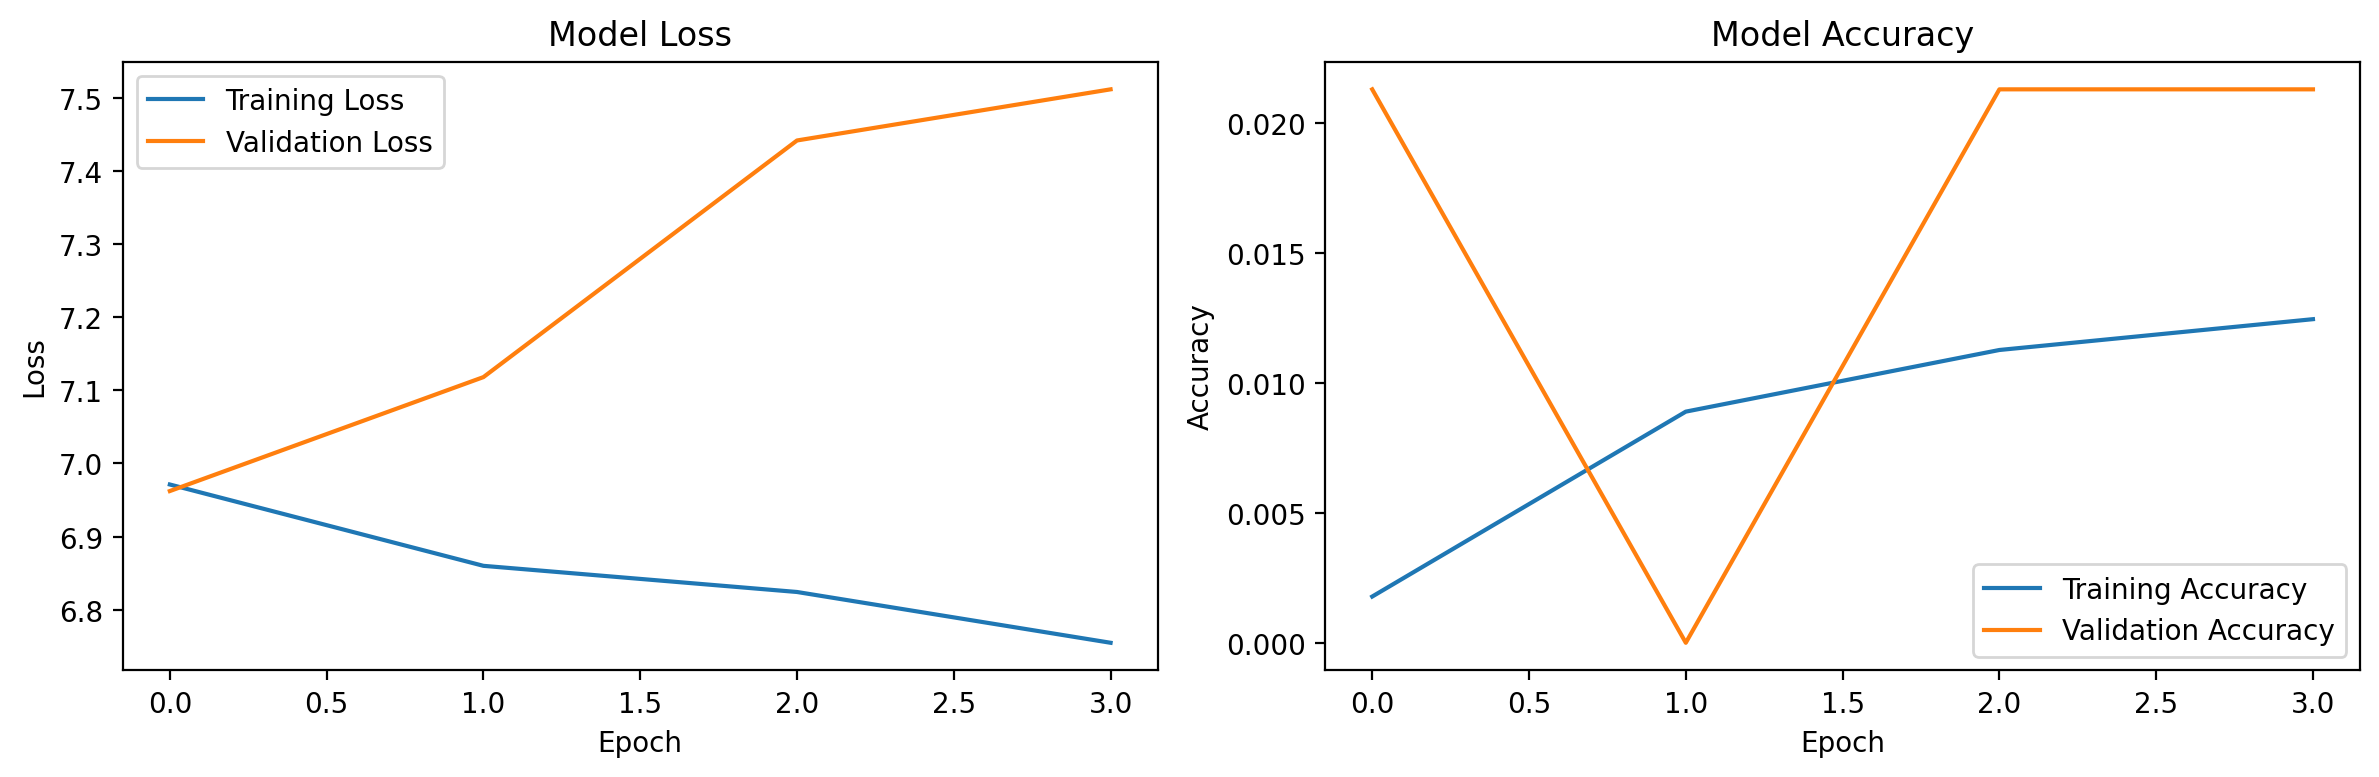

Training graph saved successfully:
/content/training-history.png


In [14]:
history_data = history.history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_data["loss"], label="Training Loss")
plt.plot(history_data["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_data["accuracy"], label="Training Accuracy")
plt.plot(history_data["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()

plt.tight_layout()

history_file = Path("/content/training-history.png")
plt.savefig(history_file, dpi=200, bbox_inches="tight")
plt.show()

print("Training graph saved successfully:")
print(history_file)